In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (244, 7)

First 5 rows:
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

Missing values:
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64


In [2]:
print("Statistical summary:")
print(df.describe())
print("\nUnique days:", df["day"].unique())
print("Unique times:", df["time"].unique())

Statistical summary:
       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.000000    2.000000
50%     17.795000    2.900000    2.000000
75%     24.127500    3.562500    3.000000
max     50.810000   10.000000    6.000000

Unique days: ['Sun' 'Sat' 'Thur' 'Fri']
Unique times: ['Dinner' 'Lunch']


      avg_tip  num_bills
day                     
Sun      3.26         76
Sat      2.99         87
Thur     2.77         62
Fri      2.73         19


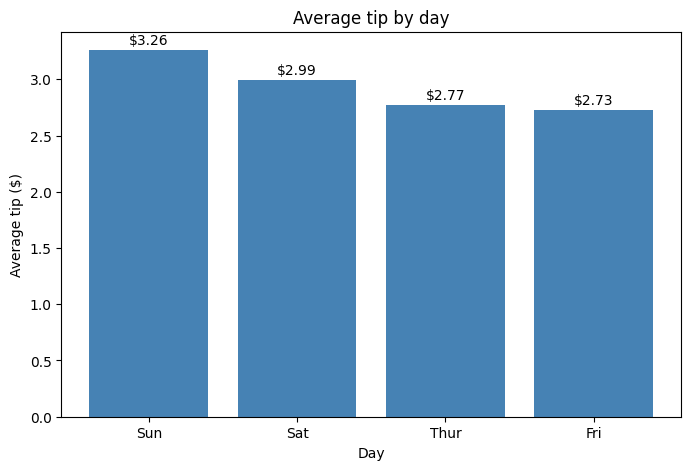

In [3]:
day_tips = df.groupby("day")["tip"].agg(["mean", "count"]).round(2)
day_tips.columns = ["avg_tip", "num_bills"]
day_tips = day_tips.sort_values("avg_tip", ascending=False)
print(day_tips)

plt.figure(figsize=(8, 5))
bars = plt.bar(day_tips.index, day_tips["avg_tip"], color="steelblue")
plt.title("Average tip by day")
plt.xlabel("Day")
plt.ylabel("Average tip ($)")
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.05,
             f"${height:.2f}", ha="center", fontsize=10)
plt.show()

Correlation between bill and tip: 0.68


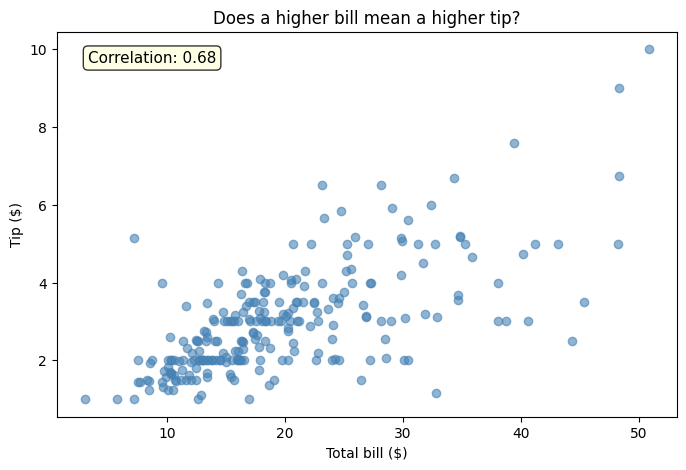

In [4]:
correlation = df["total_bill"].corr(df["tip"])
print(f"Correlation between bill and tip: {correlation:.2f}")

plt.figure(figsize=(8, 5))
plt.scatter(df["total_bill"], df["tip"], alpha=0.6, color="steelblue")
plt.title("Does a higher bill mean a higher tip?")
plt.xlabel("Total bill ($)")
plt.ylabel("Tip ($)")
plt.annotate(f"Correlation: {correlation:.2f}", xy=(0.05, 0.92),
             xycoords="axes fraction", fontsize=11,
             bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))
plt.show()

day      Fri   Sat   Sun  Thur
time                          
Dinner  2.94  2.99  3.26  3.00
Lunch   2.38   NaN   NaN  2.77


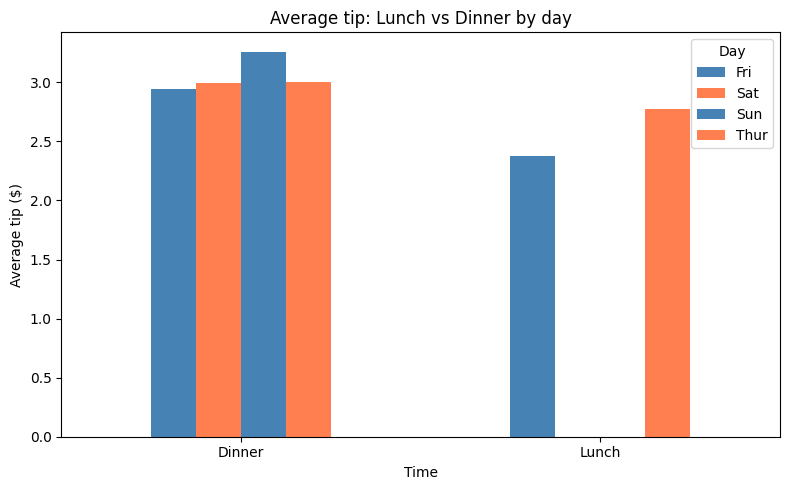

In [5]:
time_tips = df.groupby(["time", "day"])["tip"].mean().round(2).unstack()
print(time_tips)

time_tips.plot(kind="bar", figsize=(8, 5), color=["steelblue", "coral"])
plt.title("Average tip: Lunch vs Dinner by day")
plt.xlabel("Time")
plt.ylabel("Average tip ($)")
plt.legend(title="Day")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)
day_tips = df.groupby("day")["tip"].agg(["mean", "count"]).round(2)
day_tips.columns = ["avg_tip", "num_bills"]
day_tips = day_tips.sort_values("avg_tip", ascending=False)

day      Fri   Sat   Sun  Thur
time                          
Dinner  2.94  2.99  3.26  3.00
Lunch   2.38   NaN   NaN  2.77


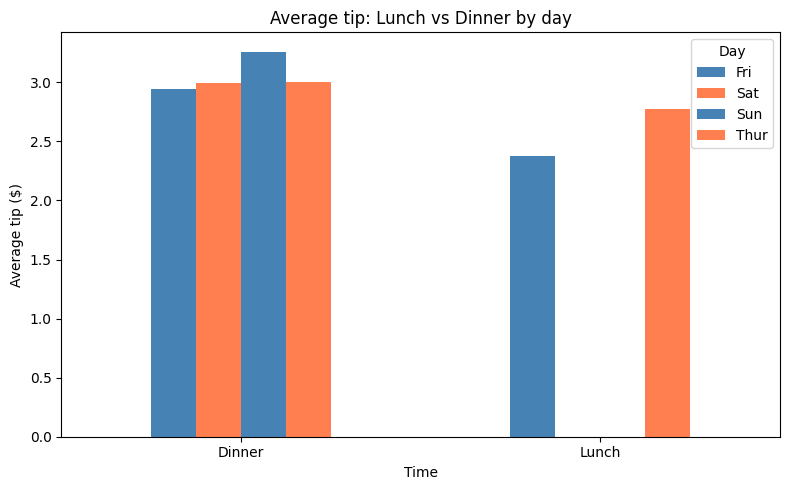

In [7]:
time_tips = df.groupby(["time", "day"])["tip"].mean().round(2).unstack()
print(time_tips)

time_tips.plot(kind="bar", figsize=(8, 5), color=["steelblue", "coral"])
plt.title("Average tip: Lunch vs Dinner by day")
plt.xlabel("Time")
plt.ylabel("Average tip ($)")
plt.legend(title="Day")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Key Findings

1. **Sunday has the highest average tip ($3.26)** — significantly above Friday ($2.73)
2. **Total bill strongly predicts tip amount** — correlation of 0.68, meaning higher bills generally lead to higher tips
3. **Dinner tips are higher than lunch** — consistent pattern across both days where comparison is possible
4. **Friday data is least reliable** — only 19 bills recorded vs 87 on Saturday

## Next Steps
- Build a regression model to predict tip amount from bill size, day, and time
- Investigate outliers — who tipped $10 on a Saturday?